In [6]:
import pandas as pd

df = pd.read_csv('student_performance.csv')
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import matplotlib.pyplot as plt

df.to_csv("/content/drive/MyDrive/student_performance.csv", index=False)
plt.savefig("/content/drive/MyDrive/correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [40]:
from google.colab import files

 #Download CSV / DB / PNG
files.download("student_performance.db")
files.download("correlation_heatmap.png")
files.download("student_analysis.ipynb")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: student_performance_cleaned.csv

In [ ]:
#import pandas as pd

#df = pd.read_csv('/student_performance.csv')
#df.head()

In [10]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [11]:
# Clean column names: remove spaces, lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')


In [12]:
#show fist 10 rows
df.head(10)

#see basic info: colums,data types,null values
df.info()

#summary statistics for numerical  columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675058 entries, 0 to 675057
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               675058 non-null  int64  
 1   weekly_self_study_hours  675058 non-null  float64
 2   attendance_percentage    675057 non-null  float64
 3   class_participation      675057 non-null  float64
 4   total_score              675057 non-null  float64
 5   grade                    675057 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 30.9+ MB


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,675058.000000,675058.000000,675057.000000,675057.000000,675057.000000
mean,337529.500000,15.033784,84.714623,5.983190,84.285468
std,194872.603347,6.901917,9.425919,1.956524,15.434945
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,168765.250000,10.300000,78.300000,4.700000,73.900000
50%,337529.500000,15.000000,85.000000,6.000000,87.500000
75%,506293.750000,19.700000,91.800000,7.300000,100.000000
max,675058.000000,40.000000,100.000000,10.000000,100.000000


In [13]:
# Remove leading/trailing spaces and make lowercase
df.columns = df.columns.str.strip().str.lower()

# Optional: replace spaces with underscores
df.columns = df.columns.str.replace(' ', '_')

# Check the cleaned columns
print(df.columns.tolist())

['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']


In [14]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())


Missing values:
 student_id                 0
weekly_self_study_hours    0
attendance_percentage      1
class_participation        1
total_score                1
grade                      1
dtype: int64


In [15]:
# Fill missing values
# Numerical columns
df[ 'weekly_self_study_hours'] = df[ 'weekly_self_study_hours'].fillna(df[ 'weekly_self_study_hours'].mean())
df['attendance_percentage'] = df['attendance_percentage'].fillna(df['attendance_percentage'].mean())
df[ 'total_score'] = df[ 'total_score'].fillna(df[ 'total_score'].mean())

# Categorical columns
df[ 'class_participation'] = df[ 'class_participation'].fillna(df[ 'class_participation'].mode()[0])
df[ 'grade'] = df[ 'grade'].fillna(df[ 'grade'].mode()[0])






In [16]:
#count duplicates
print('Duplicates:',df.duplicated().sum())

#Remove duplicates if any
df = df.drop_duplicates()


Duplicates: 0


In [17]:
df.to_csv('student_performance_cleaned', index=False)

In [18]:
import sqlite3

In [19]:
conn = sqlite3.connect("student_performance.db")
conn = sqlite3.connect("correlation_heatmap.png")
conn = sqlite3.connect("student_analysis.ipynb")


In [20]:
df.to_sql(
    "student_performance",
    conn,
    if_exists="append",
    index=False
)

675058

In [21]:
query = "SELECT * FROM student_performance LIMIT 5"
pd.read_sql(query, conn)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


total_score                1.000000
weekly_self_study_hours    0.812311
class_participation        0.000984
student_id                -0.000115
attendance_percentage     -0.001048
Name: total_score, dtype: float64


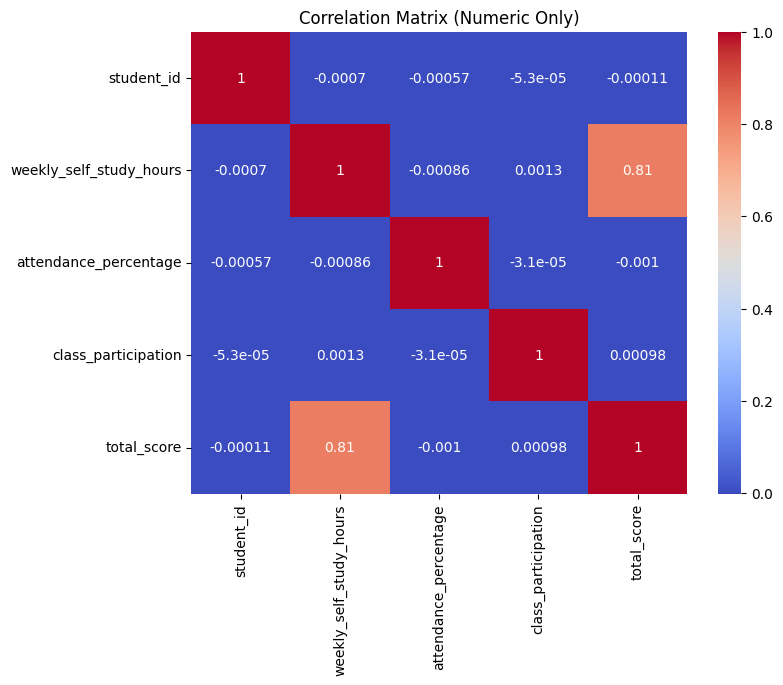

In [33]:
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Correlation matrix
corr = numeric_df.corr()
print(corr['total_score'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Only)")
plt.show()

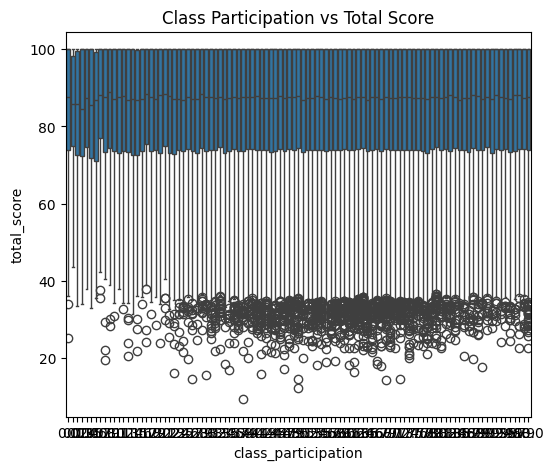

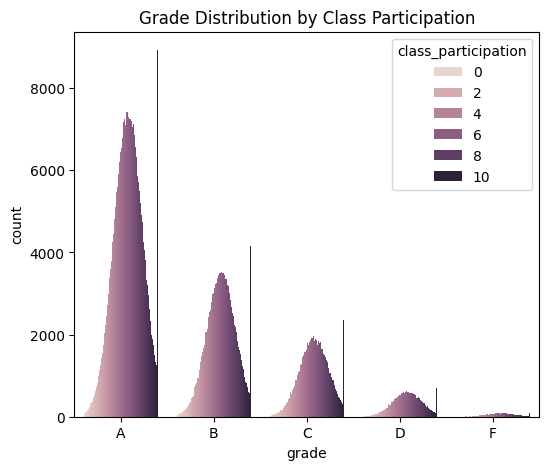

In [34]:
# Boxplot: how participation affects scores
plt.figure(figsize=(6,5))
sns.boxplot(x='class_participation', y='total_score', data=df)
plt.title("Class Participation vs Total Score")
plt.show()

# Countplot: grades per participation
plt.figure(figsize=(6,5))
sns.countplot(x='grade', hue='class_participation', data=df)
plt.title("Grade Distribution by Class Participation")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Features & target
X = df[['weekly_self_study_hours', 'attendance_percentage']]
y = df['total_score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print("Predictions (first 5):", y_pred[:5])
print("Mean Squared Error:", mse)

Predictions (first 5): [57.00866833 92.39710871 72.80061002 66.81517322 99.6524705 ]
Mean Squared Error: 80.82375815871596


In [25]:
import sqlite3

# Connect to SQLite database (or create it)
conn = sqlite3.connect("student_performance.db")

# Save dataframe as a table
df.to_sql("students", conn, if_exists="replace", index=False)

# Test query
query_result = pd.read_sql_query("SELECT * FROM students LIMIT 5;", conn)
print(query_result)

# Close connection
conn.close()

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  


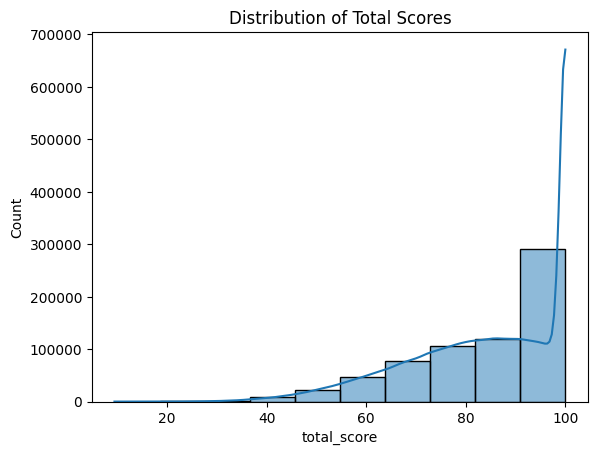

In [35]:


sns.histplot(df['total_score'], bins=10, kde=True)
plt.title("Distribution of Total Scores")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


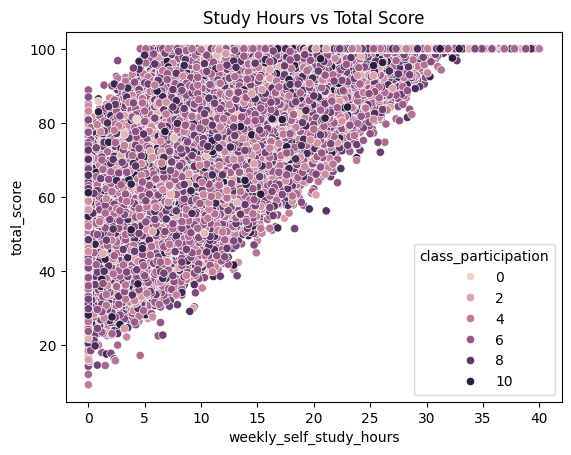

In [36]:
sns.scatterplot(x='weekly_self_study_hours', y='total_score', hue='class_participation', data=df)
plt.title("Study Hours vs Total Score")
plt.show()

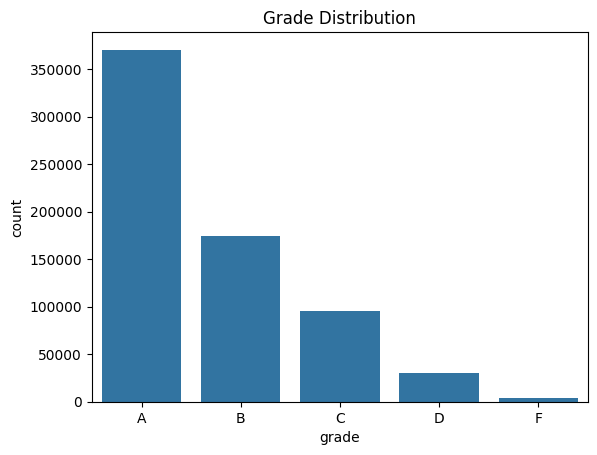

In [37]:
sns.countplot(x='grade', data=df)
plt.title("Grade Distribution")
plt.show()

In [38]:
[85.2, 77.5, 92.3, 68.4, 80.1]

[85.2, 77.5, 92.3, 68.4, 80.1]